In [2]:
# import hamiltonians
import matplotlib.pyplot as plt
import numpy as np
from utils import true_ground_state_energy_and_state

import numpy             as     np
import matplotlib        as     mpl
import matplotlib.pyplot as     plt
from   matplotlib        import rc
from   cycler            import cycler

# make sure that pdflatex is avaible for matplotlib to use
import os, shutil
texbin = "/Library/TeX/texbin"
if texbin not in os.environ.get("PATH", ""):
    os.environ["PATH"] = texbin + os.pathsep + os.environ.get("PATH", "")
print("pdflatex after fix:", shutil.which("pdflatex"))

_widths = {
    # a4paper columnwidth = 426.79135 pt = 5.93 in
    # letterpaper columnwidth = 443.57848 pt = 6.16 in
    'onecolumn': {
        'a4paper' : 5.93,
        'letterpaper' : 6.16
    },
    # a4paper columnwidth = 231.84843 pt = 3.22 in
    # letterpaper columnwidth = 240.24199 pt = 3.34 in
    'twocolumn': {
        'a4paper' : 3.22,
        'letterpaper' : 3.34
    }
}

_wide_widths = {
    # a4paper wide columnwidth = 426.79135 pt = 5.93 in
    # letterpaper wide columnwidth = 443.57848 pt = 6.16 in
    'onecolumn': {
        'a4paper' : 5.93,
        'letterpaper' : 6.16
    },
    # a4paper wide linewidth = 483.69687 pt = 6.72 in
    # letterpaper wide linewidth = 500.48400 pt = 6.95 in
    'twocolumn': {
        'a4paper' : 6.72,
        'letterpaper' : 6.95
    }
}

_fontsizes = {
    10 : {
        'tiny' : 5,
        'scriptsize' : 7,
        'footnotesize' : 8, 
        'small' : 9, 
        'normalsize' : 10,
        'large' : 12, 
        'Large' : 14, 
        'LARGE' : 17,
        'huge' : 20,
        'Huge' : 25
    },
    11 : {
        'tiny' : 6,
        'scriptsize' : 8,
        'footnotesize' : 9, 
        'small' : 10, 
        'normalsize' : 11,
        'large' : 12, 
        'Large' : 14, 
        'LARGE' : 17,
        'huge' :  20,
        'Huge' :  25
    },
    12 : {
        'tiny' : 6,
        'scriptsize' : 8,
        'footnotesize' : 10, 
        'small' : 11, 
        'normalsize' : 12,
        'large' : 14, 
        'Large' : 17, 
        'LARGE' : 20,
        'huge' :  25,
        'Huge' :  25
    }
}

_width         = 1
_wide_width    = 1
_quantumviolet = '#53257F'
_quantumgray   = '#555555'

# Sets up the plot with the fitting arguments so that the font sizes of the plot
# and the font sizes of the document are well aligned
#
#     columns : string = ('onecolumn' | 'twocolumn')
#         the columns you used to set up your quantumarticle, 
#         defaults to 'twocolumn'
#
#     paper : string = ('a4paper' | 'letterpaper')
#         the paper size you used to set up your quantumarticle,
#         defaults to 'a4paper'
#
#     fontsize : int = (10 | 11 | 12)
#         the fontsize you used to set up your quantumarticle as int
#
#     (returns) : dict
#         parameters that can be used for plot adjustments

def global_setup(columns = 'twocolumn', paper = 'a4paper', fontsize = 10):
    plt.rcdefaults()
        
    # Seaborn white is a good base style
    plt.style.use(['seaborn-v0_8-white', './quantum-plots.mplstyle'])
    
    try:        
        # This hackery is necessary so that jupyther shows the plots
        mpl.use("pgf")
        %matplotlib inline
        plt.plot()
        mpl.use("pgf")
    except:
        print('Call to matplotlib.use had no effect')
        
    mpl.interactive(False) 
    
    # Now prepare the styling that depends on the settings of the document
    
    global _width 
    _width = _widths[columns][paper]
    
    global _wide_width 
    _wide_width = _wide_widths[columns][paper]
    
    # Use the default fontsize scaling of LaTeX
    global _fontsizes
    fontsizes = _fontsizes[fontsize]
    
    plt.rcParams['axes.labelsize'] = fontsizes['small']
    plt.rcParams['axes.titlesize'] = fontsizes['large']
    plt.rcParams['xtick.labelsize'] = fontsizes['footnotesize']
    plt.rcParams['ytick.labelsize'] = fontsizes['footnotesize']
    plt.rcParams['font.size'] = fontsizes['small']
    
    return {
            'fontsizes' : fontsizes,
            'colors' : {
                'quantumviolet' : _quantumviolet,
                'quantumgray' : _quantumgray
            }
        }
    

# Sets up the plot with the fitting arguments so that the font sizes of the plot
# and the font sizes of the document are well aligned
#
#     aspect_ratio : float
#         the aspect ratio (width/height) of your plot
#         defaults to the golden ratio
#
#     width_ratio : float in [0, 1]
#         the width of your plot when you insert it into the document, e.g.
#         .8 of the regular width
#         defaults to 1.0
#
#     wide : bool 
#         indicates if the figures spans two columns in twocolumn mode, i.e.
#         when the figure* environment is used, has no effect in onecolumn mode 
#         defaults to False
#
#     (returns) : matplotlib figure object
#         the initialized figure object

def plot_setup(aspect_ratio = 1/1.62, width_ratio = 1.0, wide = False):
    width = (_wide_width if wide else _width) * width_ratio
    height = width * aspect_ratio
           
    return plt.figure(figsize=(width,height), dpi=120, facecolor='white')
    
print('Setup methods loaded')

pdflatex after fix: /Library/TeX/texbin/pdflatex
Setup methods loaded


Global props:
fontsizes :
     tiny :  5
     scriptsize :  7
     footnotesize :  8
     small :  9
     normalsize :  10
     large :  12
     Large :  14
     LARGE :  17
     huge :  20
     Huge :  25
colors :
     quantumviolet :  #53257F
     quantumgray :  #555555


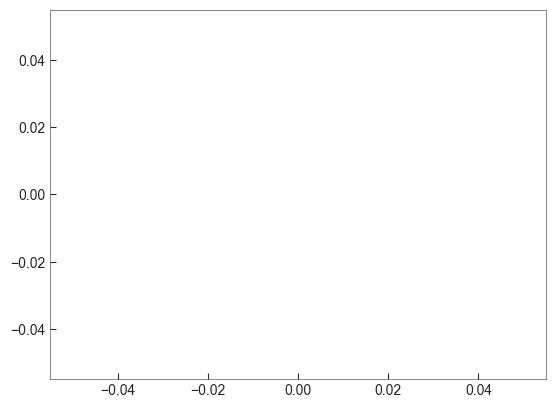

In [3]:
props = global_setup(columns = 'twocolumn', paper = 'a4paper', fontsize = 10)

print('Global props:')
for key in props:
    print(key, ':')
    for subkey in props[key]:
        print('    ', subkey, ': ', props[key][subkey])

In [5]:
n_qubits = list(range(4,13))
n_layers = list(range(1,11))
mus = list(np.sort(np.concatenate((np.linspace(-4,4,17),[-0.7]))))
n_trials = 10

true_gs = np.load('true_gs_schwinger.npy')
colors = plt.cm.viridis(np.linspace(0,1,10))
rel_err = np.load('Schwinger_rel_err.npy')
rel_err_std = np.load('Schwinger_rel_err_std.npy')

In [6]:
import matplotlib

cmap = plt.get_cmap("viridis", 9)
# plot relative error as a function of n_qubits at fixed n_layers
fig = plot_setup(aspect_ratio = 0.5)
ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2,sharey=ax0,sharex=ax0)
mu_ind = -1

for i,nl in enumerate(n_layers[:-1]):
    ax0.plot(n_qubits[:-2],rel_err[0:-2,mu_ind,i],color=cmap(i))
    ax0.fill_between(n_qubits[:-2], rel_err[0:-2,mu_ind,i] - rel_err_std[0:-2,mu_ind,i],
                     rel_err[0:-2,mu_ind,i] + rel_err_std[0:-2,mu_ind,i], color=cmap(i))

mu_ind = 7
for i,nl in enumerate(n_layers[:-1]):
    # ax.plot(n_qubits[:-2][::2],rel_err[0:-2:2,0,i],label=f'{nl} layers')
    ax1.plot(n_qubits[:-2],rel_err[0:-2,mu_ind,i],color=cmap(i))
    ax1.fill_between(n_qubits[:-2], rel_err[0:-2,mu_ind,i] - rel_err_std[0:-2,mu_ind,i],
                     rel_err[0:-2,mu_ind,i] + rel_err_std[0:-2,mu_ind,i], color=cmap(i))
# ax.legend()
ax0.set_yscale('log')
ax1.set_yscale('log')
ax0.set_xticks(n_qubits[:-2])
# ax1.set_xticks(n_qubits[:-2][::2])
# ax0.set_xlabel('size of Hamiltonian in qubits')
# ax1.set_xlabel('size of Hamiltonian in qubits')

ax1.tick_params('y', labelleft=False)
fig.supxlabel('size of Hamiltonian in qubits', y= - 0.07, fontsize=_fontsizes[10]['small'])

ax0.set_ylabel('$\Delta E / E_{gs}$')


norm= matplotlib.colors.BoundaryNorm(np.arange(2,10+2)-0.5, 10)

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
s_m.set_array([])

colbar = fig.colorbar(s_m,ticks = np.arange(2,11),fraction=0.046, pad=0.04,ax=ax1)
colbar.set_label('\# decoration layers')
fig.savefig('schwingerpl-1-0.7_all_qubits.pdf', bbox_inches='tight')


In [ ]:
# evaluate the ground state energy for the linear XY model
n_qubits = list(range(4,13))
n_layers = list(range(1,11))
gs = list(np.linspace(-1,1,9))
z_noise = 0.01
n_trials = 10

true_gs_XY = np.load('true_gs_XY.npy')
rel_err_XY = np.load('linear_XY_rel_err.npy')
rel_err_std_XY = np.load('linear_XY_rel_err_std.npy')

In [ ]:
g_ind = -1

cmap = plt.get_cmap("viridis", 9)
# plot relative error as a function of n_qubits at fixed n_layers
fig = plot_setup(aspect_ratio = 0.5)
ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2, sharey=ax0,sharex=ax0)

for i,nl in enumerate(n_layers[:-1]):
    ax0.plot(n_qubits[:-2],rel_err_XY[:-2,g_ind,i],color=cmap(i))
    ax0.fill_between(n_qubits[:-2], rel_err_XY[:-2,g_ind,i] - rel_err_std_XY[:-2,g_ind,i], rel_err_XY[:-2,g_ind,i] + rel_err_std_XY[:-2,g_ind,i], color=cmap(i))

g_ind = 4
for i,nl in enumerate(n_layers[:-1]):
    ax1.plot(n_qubits[:-2],rel_err_XY[:-2,g_ind,i],color=cmap(i))
    ax1.fill_between(n_qubits[:-2], rel_err_XY[:-2,g_ind,i] - rel_err_std_XY[:-2,g_ind,i], rel_err_XY[:-2,g_ind,i] + rel_err_std_XY[:-2,g_ind,i], color=cmap(i))

ax0.set_yscale('log')
ax1.set_yscale('log')

ax0_ylim = ax0.get_ylim()

ax1.tick_params('y', labelleft=False)
fig.supxlabel('size of Hamiltonian in qubits', y= - 0.07, fontsize=_fontsizes[10]['small'])

ax0.set_xticks(n_qubits[:-2])
ax1.set_xticks(n_qubits[:-2])

ax0.set_ylabel('$\Delta E / E_{gs}$')
norm= matplotlib.colors.BoundaryNorm(np.arange(2,10+2)-0.5, 10)
s_m = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
s_m.set_array([])

colbar = fig.colorbar(s_m,ticks = np.arange(2,11),fraction=0.046, pad=0.04,ax=ax1)
colbar.set_label('\# decoration layers')

fig.savefig('XYpl10_new2.pdf', bbox_inches='tight')



In [ ]:

rel_err_XY_wou = np.load('linear_XY_rel_err_wou.npy')
rel_err_std_XY_wou = np.load('linear_XY_rel_err_std_wou.npy')

# plot relative error as a function of n_qubits at fixed n_layers
g_ind = -1

cmap = plt.get_cmap("viridis", 9)
# plot relative error as a function of n_qubits at fixed n_layers
# fig, ax = plt.subplots(1,2,)
fig = plot_setup(aspect_ratio = 0.5)
ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)
for i,nl in enumerate(n_layers[:-1]):
    ax0.plot(n_qubits[:-2],rel_err_XY_wou[:-2,g_ind,i],color=cmap(i))
    ax0.fill_between(n_qubits[:-2], rel_err_XY_wou[:-2,g_ind,i] - rel_err_std_XY_wou[:-2,g_ind,i],
                        rel_err_XY_wou[:-2,g_ind,i] + rel_err_std_XY_wou[:-2,g_ind,i], color=cmap(i))

g_ind = 4
for i,nl in enumerate(n_layers[:-1]):
    ax1.plot(n_qubits[:-2],rel_err_XY_wou[:-2,g_ind,i],color=cmap(i))
    ax1.fill_between(n_qubits[:-2], rel_err_XY_wou[:-2,g_ind,i] - rel_err_std_XY_wou[:-2,g_ind,i],
                        rel_err_XY_wou[:-2,g_ind,i] + rel_err_std_XY_wou[:-2,g_ind,i], color=cmap(i))

ax0.set_yscale('log')
ax1.set_yscale('log')

ax0.set_ylim(ax0_ylim)
ax1.set_ylim(ax0_ylim)

ax0.set_xticks(n_qubits[:-2])
ax1.set_xticks(n_qubits[:-2])

ax1.tick_params('y', labelleft=False)
fig.supxlabel('size of Hamiltonian in qubits', y= - 0.07, fontsize=_fontsizes[10]['small'])

ax0.set_ylabel('$\Delta E / E_{gs}$')
norm= matplotlib.colors.BoundaryNorm(np.arange(2,10+2)-0.5, 10)
s_m = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
s_m.set_array([])

colbar = fig.colorbar(s_m,ticks = np.arange(2,11),fraction=0.046, pad=0.04,ax=ax1)
colbar.set_label('\# decoration layers')

fig.savefig('XYplwou_new2.pdf', bbox_inches='tight')